### 1. Data Loading and Initial Preprocessing
This cell imports the necessary libraries, loads the preprocessed ride booking dataset, converts the datetime column, and aggregates the data into daily booking counts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('rideBookings_preprocessed1.xlsx')
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Daily demand
daily = df.groupby(df['Datetime'].dt.date)['Datetime'].count().reset_index(name='demand')
daily.columns = ['Date', 'demand']
daily['Date'] = pd.to_datetime(daily['Date'])
daily = daily.set_index('Date').sort_index()

train = daily['demand']
print("Data range:", train.index[0].date(), "→", train.index[-1].date())
print("Total days:", len(train))
print(train.describe().round(2))

Data range: 2024-01-01 → 2024-12-30
Total days: 365
count    365.00
mean     407.58
std       20.74
min      355.00
25%      393.00
50%      408.00
75%      423.00
max      461.00
Name: demand, dtype: float64


### 2. Stationarity Test (Augmented Dickey-Fuller)
To ensure valid time-series modeling, we perform an ADF test to check if the series is stationary. If the p-value is low, we can proceed without differencing (d=0).

In [2]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)
print(f"\nADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Critical 1%   : {result[4]['1%']:.4f}")
print(f"Critical 5%   : {result[4]['5%']:.4f}")

if result[1] < 0.05:
    print("\n→ Series is STATIONARY (d=0)")
    d_order = 0
else:
    print("\n→ Series is NON-STATIONARY (use d=1)")
    d_order = 1


ADF Statistic : -18.3971
p-value       : 0.0000
Critical 1%   : -3.4484
Critical 5%   : -2.8695

→ Series is STATIONARY (d=0)


### 3. ACF and PACF Analysis
Visualizing Auto-Correlation and Partial Auto-Correlation functions helps determine the potential orders for Autoregressive (p) and Moving Average (q) components.

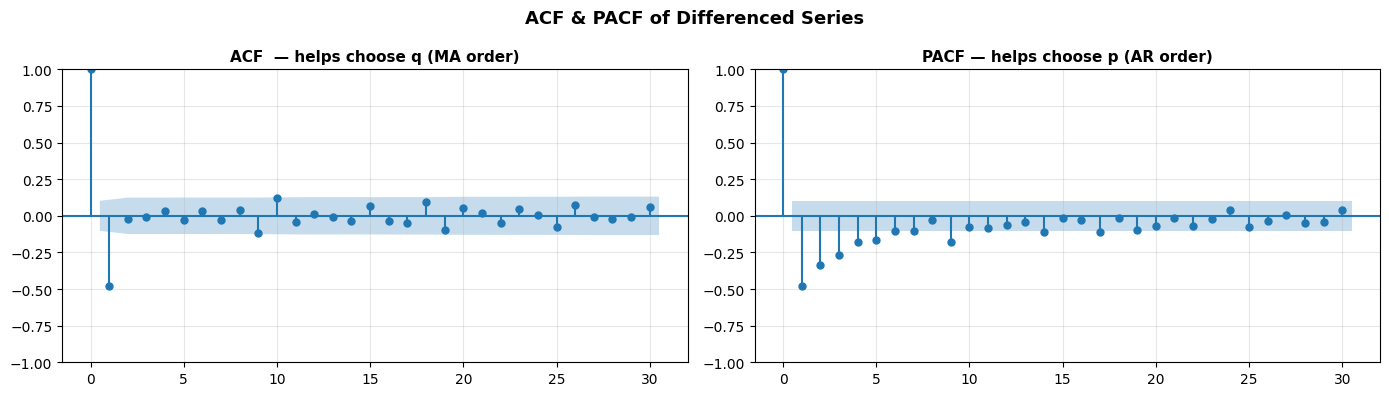

Rule: PACF cuts off at lag p → AR order | ACF cuts off at lag q → MA order


In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train.diff().dropna(),  lags=30, ax=axes[0])
plot_pacf(train.diff().dropna(), lags=30, ax=axes[1])
axes[0].set_title('ACF  — helps choose q (MA order)', fontsize=11, fontweight='bold')
axes[1].set_title('PACF — helps choose p (AR order)', fontsize=11, fontweight='bold')
for ax in axes:
    ax.grid(alpha=0.3)
plt.suptitle('ACF & PACF of Differenced Series', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rule: PACF cuts off at lag p → AR order | ACF cuts off at lag q → MA order")

### 4. ARIMA Hyperparameter Tuning
This cell performs a grid search over various combinations of (p, d, q) to find the ARIMA model with the lowest Akaike Information Criterion (AIC).

In [4]:
print("\nSearching best ARIMA(p,d,q) order...")
from statsmodels.tsa.arima.model import ARIMA

best_aic   = np.inf
best_order = None
results_grid = []

for p, d, q in itertools.product(range(0, 4), [d_order], range(0, 4)):
    try:
        model = ARIMA(train, order=(p, d, q)).fit()
        results_grid.append({'order': (p,d,q), 'AIC': round(model.aic, 2),
                              'BIC': round(model.bic, 2)})
        if model.aic < best_aic:
            best_aic   = model.aic
            best_order = (p, d, q)
    except:
        continue

grid_df = pd.DataFrame(results_grid).sort_values('AIC').head(10)
print("\nTop 10 ARIMA orders by AIC:")
print(grid_df.to_string(index=False))
print(f"\nBest order selected: ARIMA{best_order}  AIC={best_aic:.2f}")


Searching best ARIMA(p,d,q) order...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat


Top 10 ARIMA orders by AIC:
    order     AIC     BIC
(0, 0, 0) 3252.15 3259.95
(0, 0, 1) 3253.79 3265.49
(1, 0, 0) 3253.79 3265.49
(0, 0, 2) 3255.79 3271.39
(1, 0, 1) 3255.79 3271.39
(2, 0, 0) 3255.79 3271.39
(2, 0, 3) 3256.53 3283.83
(3, 0, 2) 3256.55 3283.85
(3, 0, 0) 3257.75 3277.25
(0, 0, 3) 3257.77 3277.27

Best order selected: ARIMA(0, 0, 0)  AIC=3252.15


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 5. Forecasting Utility Setup
We define a global forecast horizon and a robust plotting function that generates daily views, monthly averages, and monthly totals for all subsequent models.

In [5]:
FORECAST_DAYS = 90
last_date     = train.index[-1]
future_index  = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=FORECAST_DAYS, freq='D'
)

forecasts = {}   # store all model forecasts
metrics   = {}   # store monthly summaries

def plot_forecast(title, pred, lower, upper, color, filename, model_name):
    fig, axes = plt.subplots(3, 1, figsize=(16, 14))

    # --- Plot 1: Full view with history ---
    ax = axes[0]
    ax.plot(train.iloc[-60:].index, train.iloc[-60:].values,
            color='steelblue', linewidth=1.8, label='Historical (last 60 days)')
    ax.plot(future_index, pred,
            color=color, linewidth=2, linestyle='--', label=f'{model_name} Forecast')
    ax.fill_between(future_index, lower, upper,
                    color=color, alpha=0.15, label='95% CI')
    ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=1.2)
    ax.text(last_date, train.iloc[-60:].max() * 0.98,
            '  Forecast\n  Start', fontsize=9, color='gray')
    for ms in pd.date_range(future_index[0], future_index[-1], freq='MS'):
        ax.axvline(x=ms, color='lightgray', linestyle=':', linewidth=0.8)
        ax.text(ms, lower.min(), ms.strftime('%b %Y'),
                fontsize=8, color='dimgray', rotation=90, va='bottom')
    ax.set_title(f'{title} — Full Forecast View', fontsize=12, fontweight='bold')
    ax.set_ylabel('Bookings/Day'); ax.legend(); ax.grid(alpha=0.3)

    # --- Plot 2: Month-by-month breakdown ---
    pred_s  = pd.Series(pred,  index=future_index)
    lower_s = pd.Series(lower, index=future_index)
    upper_s = pd.Series(upper, index=future_index)
    months  = pred_s.resample('ME').apply(list)

    ax2 = axes[1]
    for ms in pd.date_range(future_index[0], future_index[-1], freq='MS'):
        ax2.axvline(x=ms, color='lightgray', linestyle=':', linewidth=0.8)
    ax2.plot(future_index, pred_s.values, color=color,
             linewidth=1.5, marker='o', markersize=2.5, label='Daily Forecast')
    ax2.fill_between(future_index, lower_s, upper_s, color=color, alpha=0.15)
    # Monthly average line
    monthly_mean = pred_s.resample('ME').mean()
    for period, val in monthly_mean.items():
        month_days = pred_s[pred_s.index.to_period('M') == period.to_period('M')]
        ax2.hlines(val, month_days.index[0], month_days.index[-1],
                   color=color, linewidth=2.5, alpha=0.6)
        ax2.text(month_days.index[len(month_days)//2], val + 1,
                 f'avg {val:.0f}', ha='center', fontsize=9,
                 color=color, fontweight='bold')
    ax2.set_title('Daily Forecast with Monthly Averages', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Bookings/Day'); ax2.legend(); ax2.grid(alpha=0.3)

    # --- Plot 3: Monthly totals bar ---
    monthly_total = pred_s.resample('ME').sum()
    month_labels  = [d.strftime('%b %Y') for d in monthly_total.index]
    ax3 = axes[2]
    bars = ax3.bar(month_labels, monthly_total.values,
                   color=color, edgecolor='white', width=0.4, alpha=0.85)
    for bar, val in zip(bars, monthly_total.values):
        ax3.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 f'{int(val):,}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
    ax3.set_title('Total Forecasted Bookings per Month', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Total Bookings'); ax3.grid(axis='y', alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")
    return monthly_total

### 6. ARIMA Model Fitting & Forecast
Here we fit the best-selected ARIMA model to the full dataset and generate a 90-day demand forecast with confidence intervals.


Fitting ARIMA(0, 0, 0)...
                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                  365
Model:                          ARIMA   Log Likelihood               -1624.075
Date:                Sat, 09 May 2026   AIC                           3252.149
Time:                        04:33:40   BIC                           3259.949
Sample:                    01-01-2024   HQIC                          3255.249
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        407.5808      1.084    375.890      0.000     405.456     409.706
sigma2       428.8869     37.065     11.571      0.000     356.240     501.534
Ljung-Box (L1) (Q):      

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


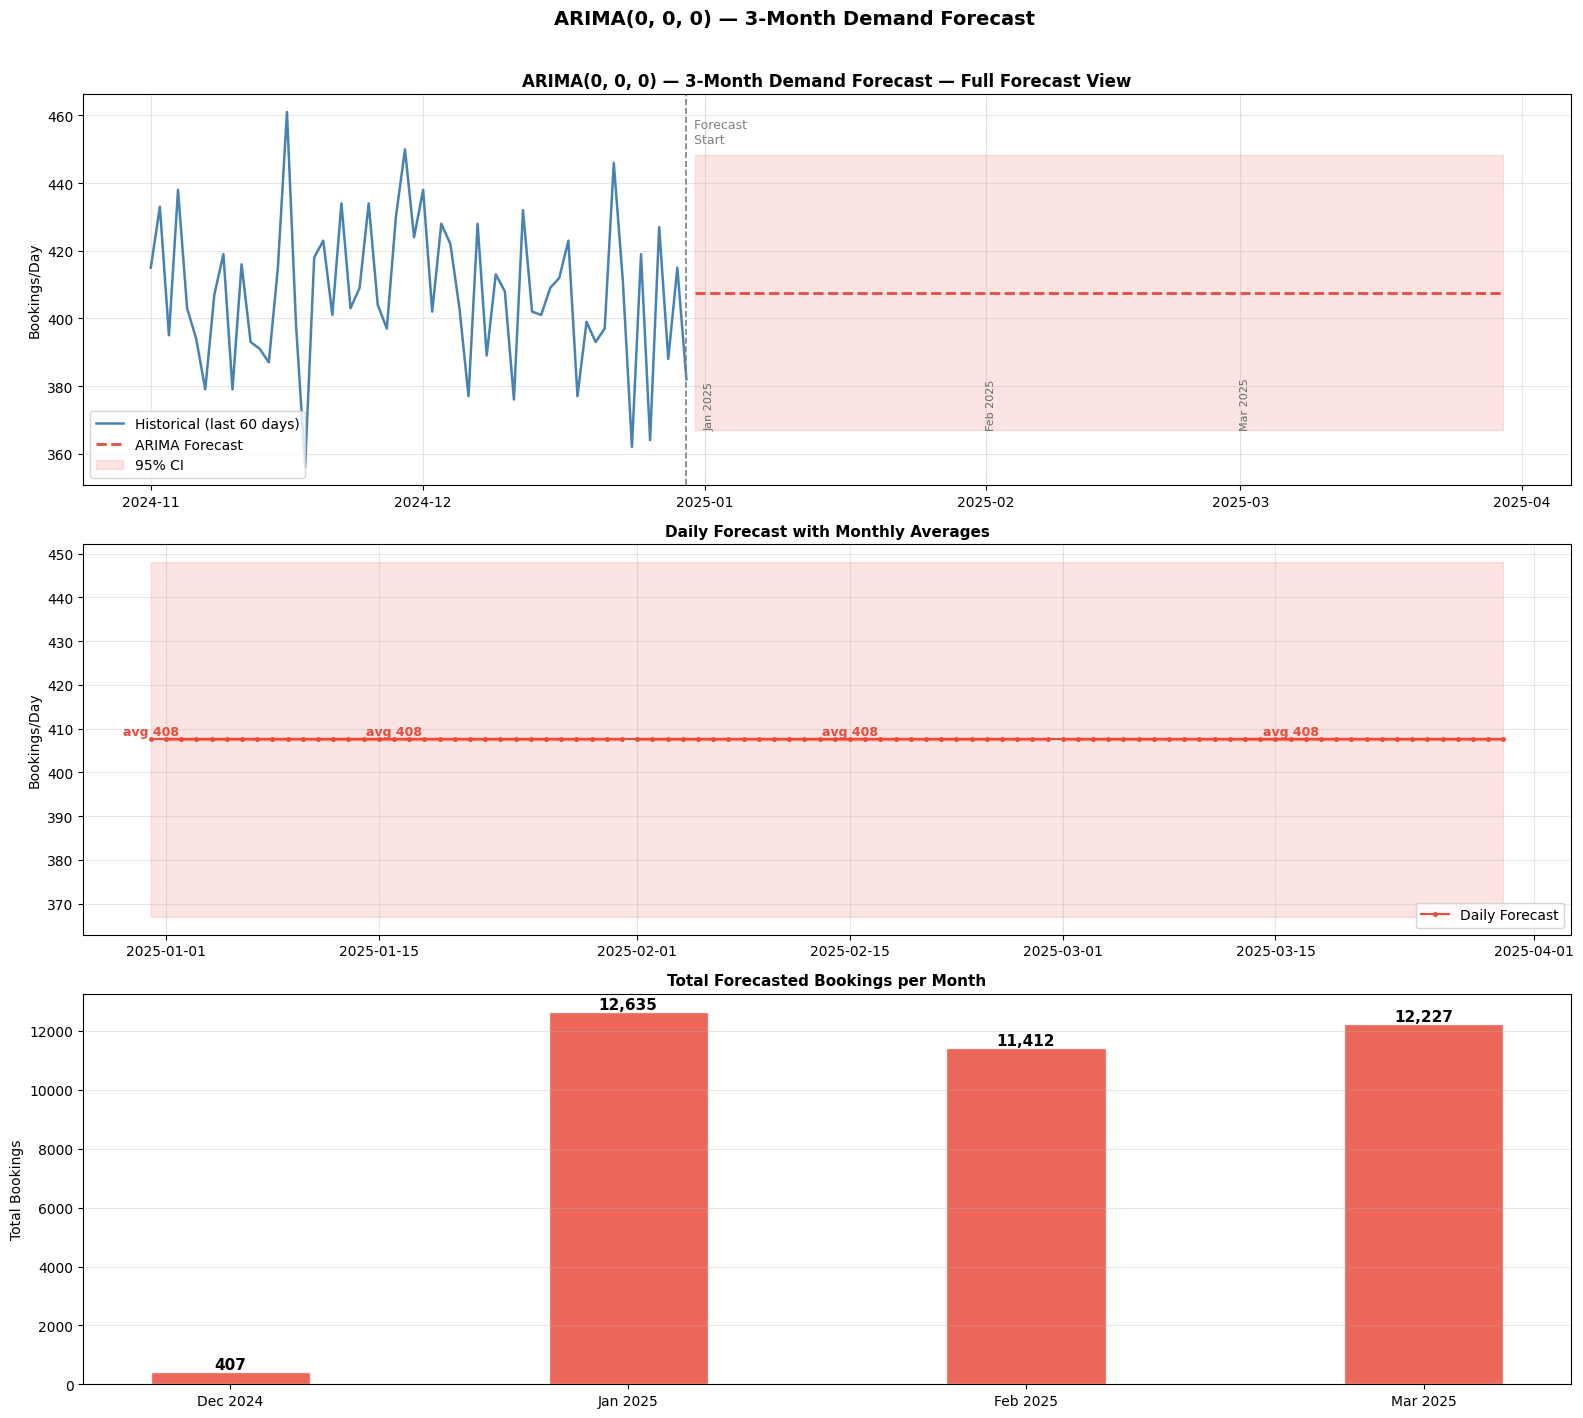

Saved: arima_forecast.png


In [6]:
print(f"\nFitting ARIMA{best_order}...")
arima_fit    = ARIMA(train, order=best_order).fit()
arima_obj    = arima_fit.get_forecast(steps=FORECAST_DAYS)
arima_pred   = arima_obj.predicted_mean.clip(lower=0).values
arima_ci     = arima_obj.conf_int(alpha=0.05).clip(lower=0)
arima_lower  = arima_ci.iloc[:, 0].values
arima_upper  = arima_ci.iloc[:, 1].values

print(arima_fit.summary())

forecasts['ARIMA'] = arima_pred
metrics['ARIMA'] = plot_forecast(
    title      = f'ARIMA{best_order} — 3-Month Demand Forecast',
    pred       = arima_pred,
    lower      = arima_lower,
    upper      = arima_upper,
    color      = '#E74C3C',
    filename   = 'arima_forecast.png',
    model_name = 'ARIMA'
)

### 7. SARIMA Model (Seasonal ARIMA)
We fit a Seasonal ARIMA model to explicitly account for the weekly patterns observed in the booking data.


Fitting SARIMA(1,1,1)(1,1,1,7)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


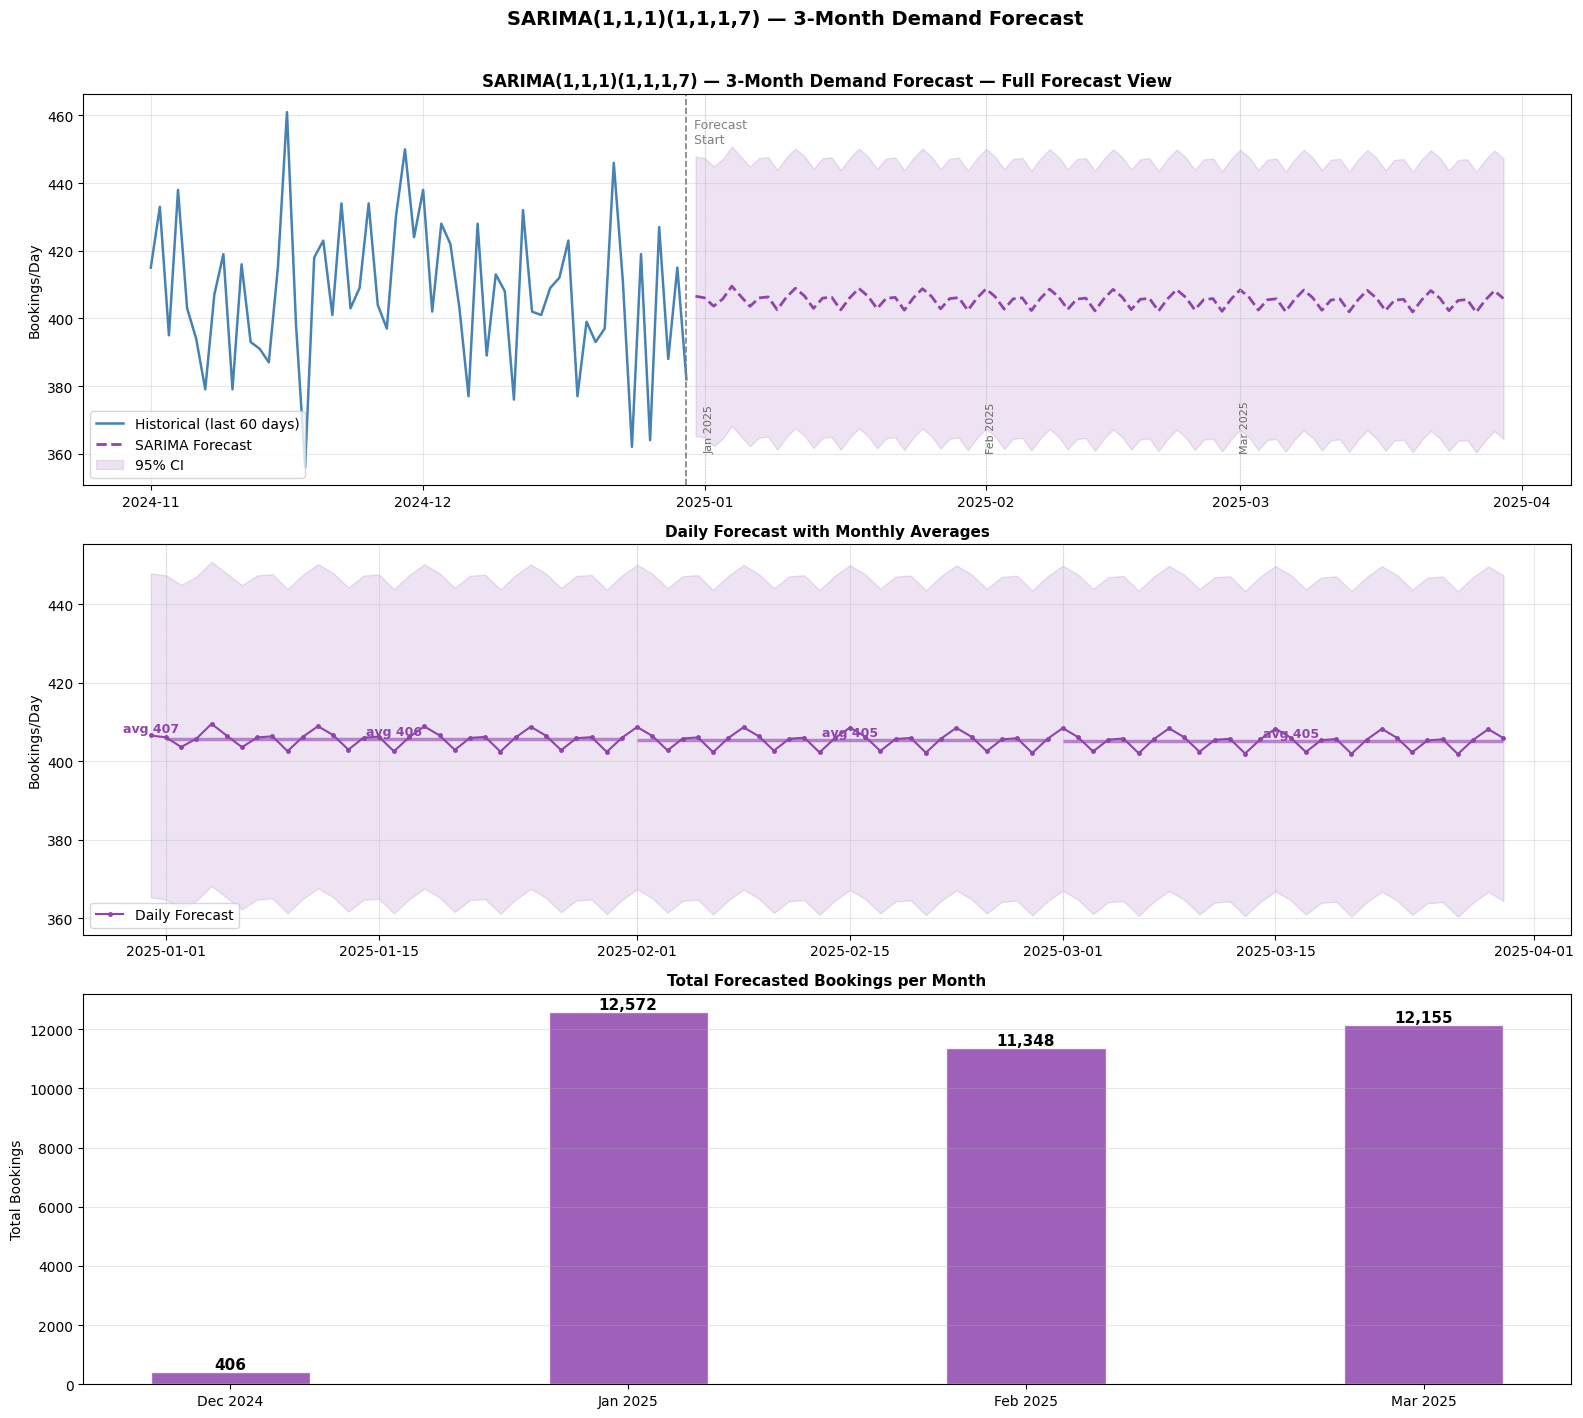

Saved: sarima_forecast.png


In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("\nFitting SARIMA(1,1,1)(1,1,1,7)...")
sarima_fit   = SARIMAX(train,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 7)).fit(disp=False)
sarima_obj   = sarima_fit.get_forecast(steps=FORECAST_DAYS)
sarima_pred  = sarima_obj.predicted_mean.clip(lower=0).values
sarima_ci    = sarima_obj.conf_int(alpha=0.05).clip(lower=0)
sarima_lower = sarima_ci.iloc[:, 0].values
sarima_upper = sarima_ci.iloc[:, 1].values

forecasts['SARIMA'] = sarima_pred
metrics['SARIMA'] = plot_forecast(
    title      = 'SARIMA(1,1,1)(1,1,1,7) — 3-Month Demand Forecast',
    pred       = sarima_pred,
    lower      = sarima_lower,
    upper      = sarima_upper,
    color      = '#8E44AD',
    filename   = 'sarima_forecast.png',
    model_name = 'SARIMA'
)

### 8. Holt-Winters Exponential Smoothing
This cell applies Triple Exponential Smoothing (Additive) to capture both the local level and the additive seasonality of the demand.


Fitting Holt-Winters...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


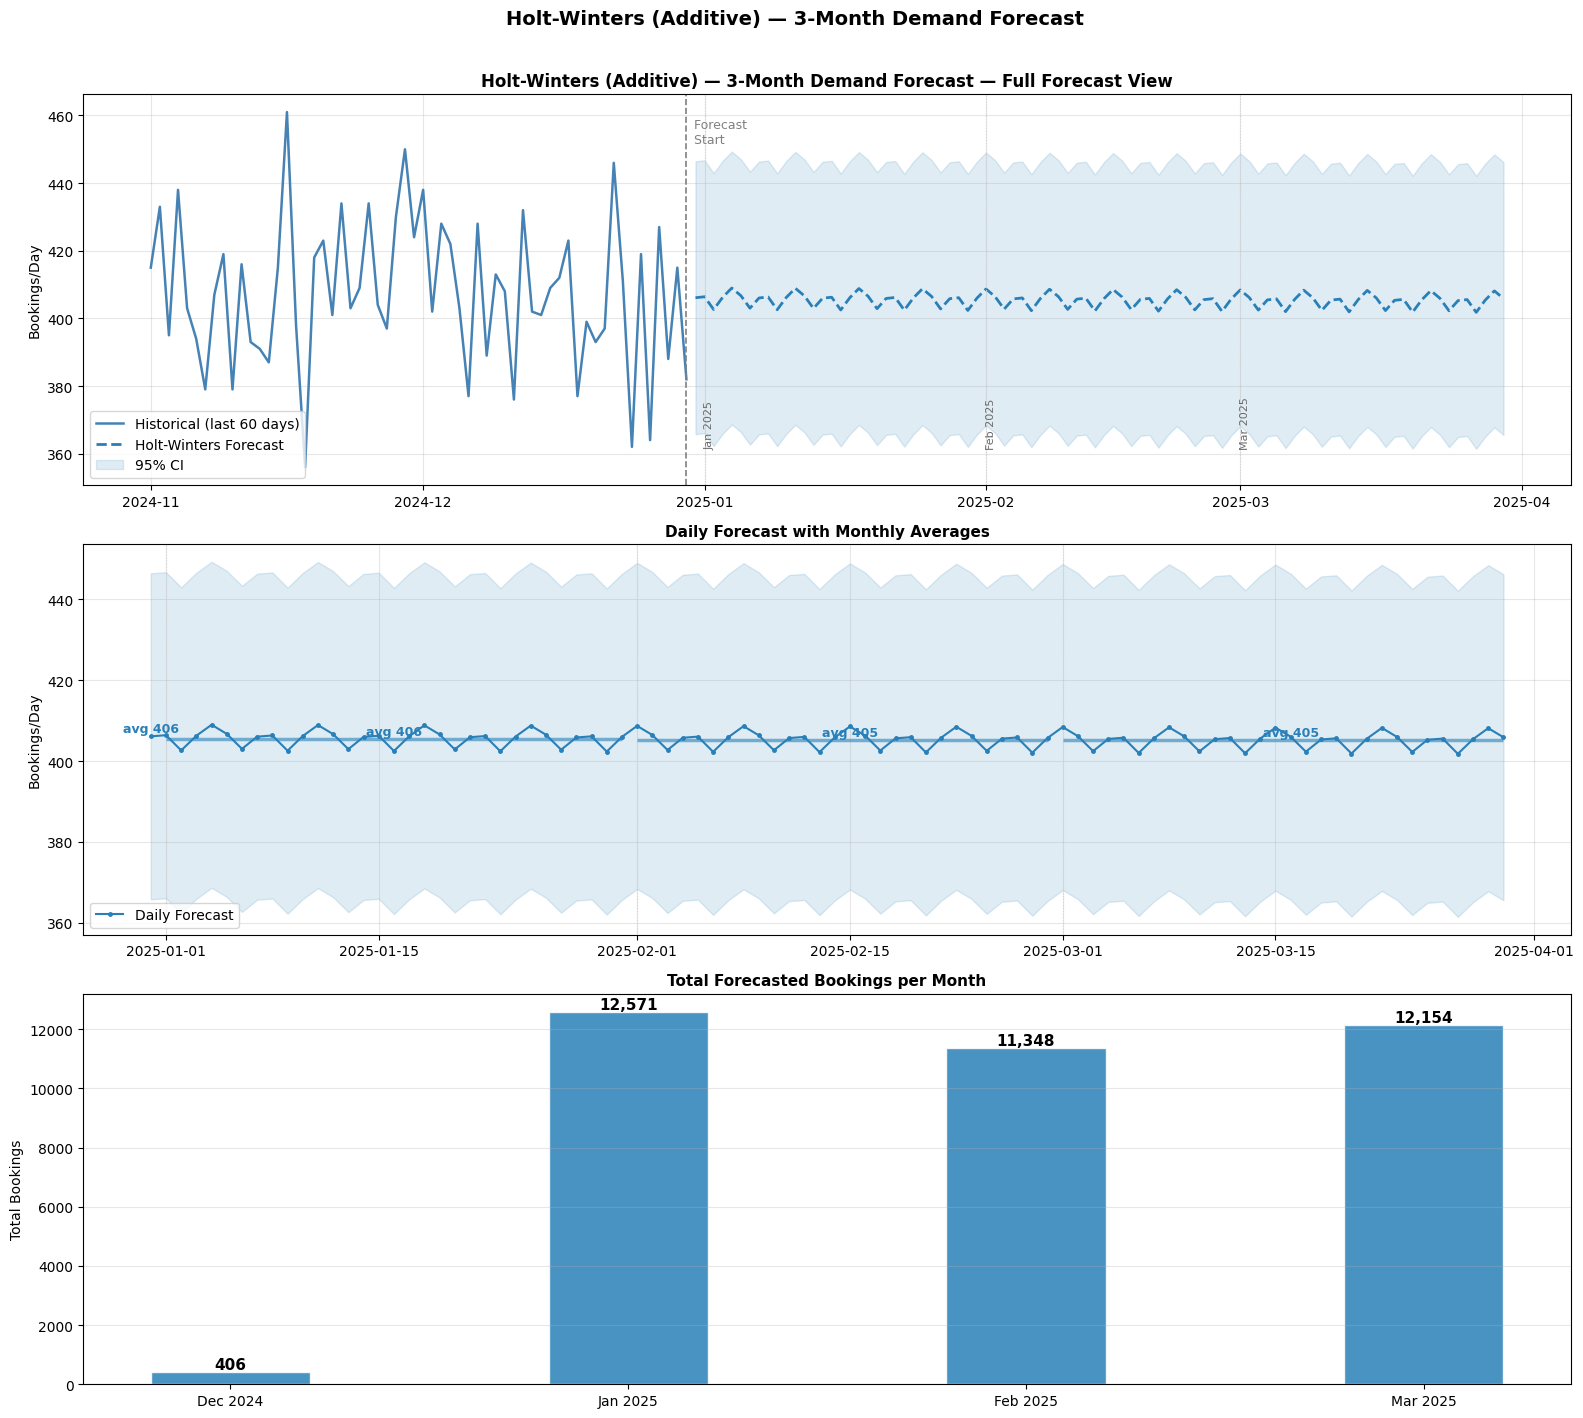

Saved: holtwinters_forecast.png


In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("\nFitting Holt-Winters...")
hw_fit   = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=7
).fit()

hw_pred  = hw_fit.forecast(FORECAST_DAYS).clip(lower=0).values

# Holt-Winters has no built-in CI — simulate with residual std
resid_std  = np.std(hw_fit.resid)
hw_lower   = (hw_pred - 1.96 * resid_std).clip(min=0)
hw_upper   = hw_pred + 1.96 * resid_std

forecasts['HoltWinters'] = hw_pred
metrics['HoltWinters'] = plot_forecast(
    title      = 'Holt-Winters (Additive) — 3-Month Demand Forecast',
    pred       = hw_pred,
    lower      = hw_lower,
    upper      = hw_upper,
    color      = '#2980B9',
    filename   = 'holtwinters_forecast.png',
    model_name = 'Holt-Winters'
)

### 9. Facebook Prophet Model
Prophet is used here to handle seasonality and holidays automatically. It provides a robust alternative to classical statistical models.


Fitting Prophet...


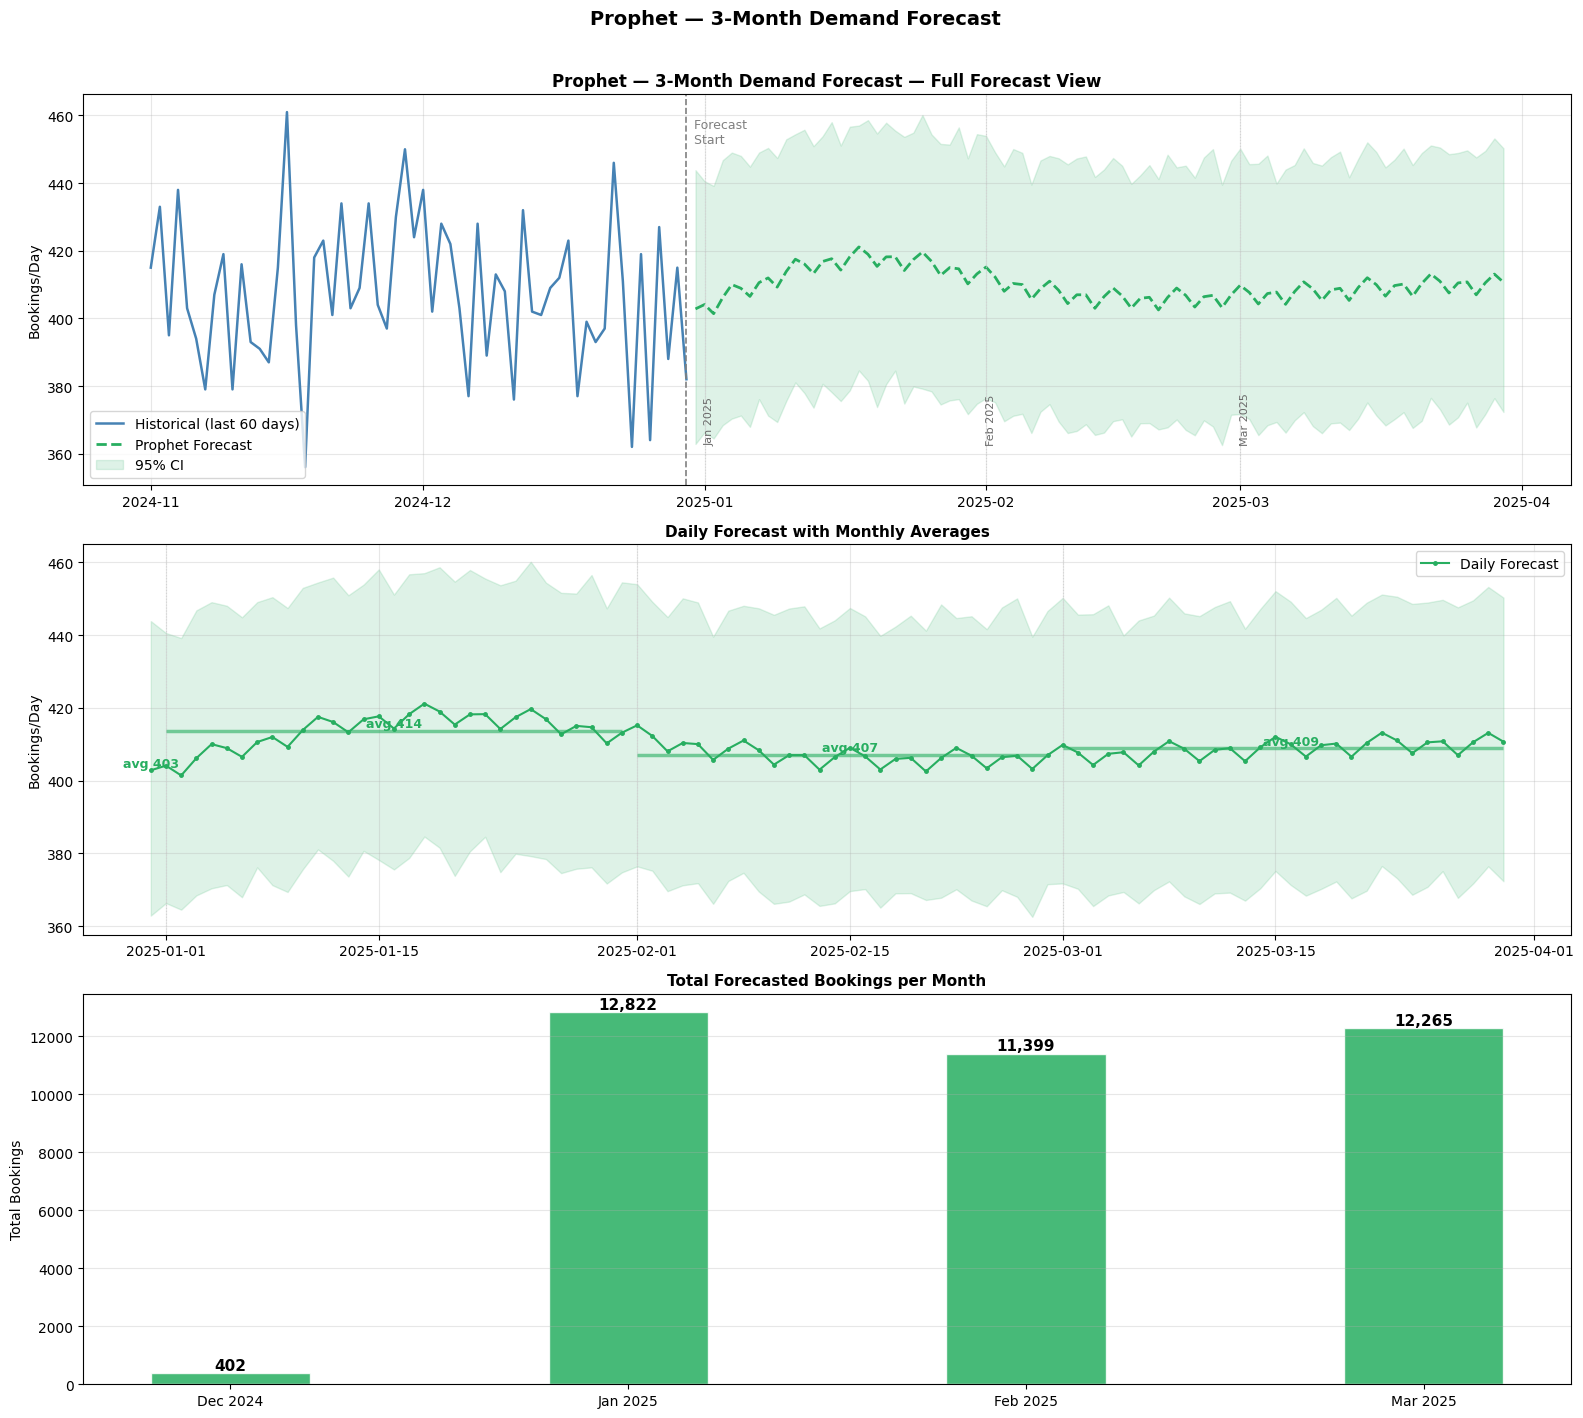

Saved: prophet_forecast.png


In [9]:
from prophet import Prophet

print("\nFitting Prophet...")
prophet_df = train.reset_index()
prophet_df.columns = ['ds', 'y']

prophet_model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    seasonality_mode    = 'additive',
    interval_width      = 0.95
)
prophet_model.fit(prophet_df)

future_df      = prophet_model.make_future_dataframe(periods=FORECAST_DAYS, freq='D')
prophet_result = prophet_model.predict(future_df)
prophet_tail   = prophet_result.tail(FORECAST_DAYS)

prophet_pred  = prophet_tail['yhat'].clip(lower=0).values
prophet_lower = prophet_tail['yhat_lower'].clip(lower=0).values
prophet_upper = prophet_tail['yhat_upper'].values

forecasts['Prophet'] = prophet_pred
metrics['Prophet'] = plot_forecast(
    title      = 'Prophet — 3-Month Demand Forecast',
    pred       = prophet_pred,
    lower      = prophet_lower,
    upper      = prophet_upper,
    color      = '#27AE60',
    filename   = 'prophet_forecast.png',
    model_name = 'Prophet'
)

### 10. Multi-Model Comparison Visualization
This chart overlays all generated forecasts on a single plot to compare trends and identify where models diverge.

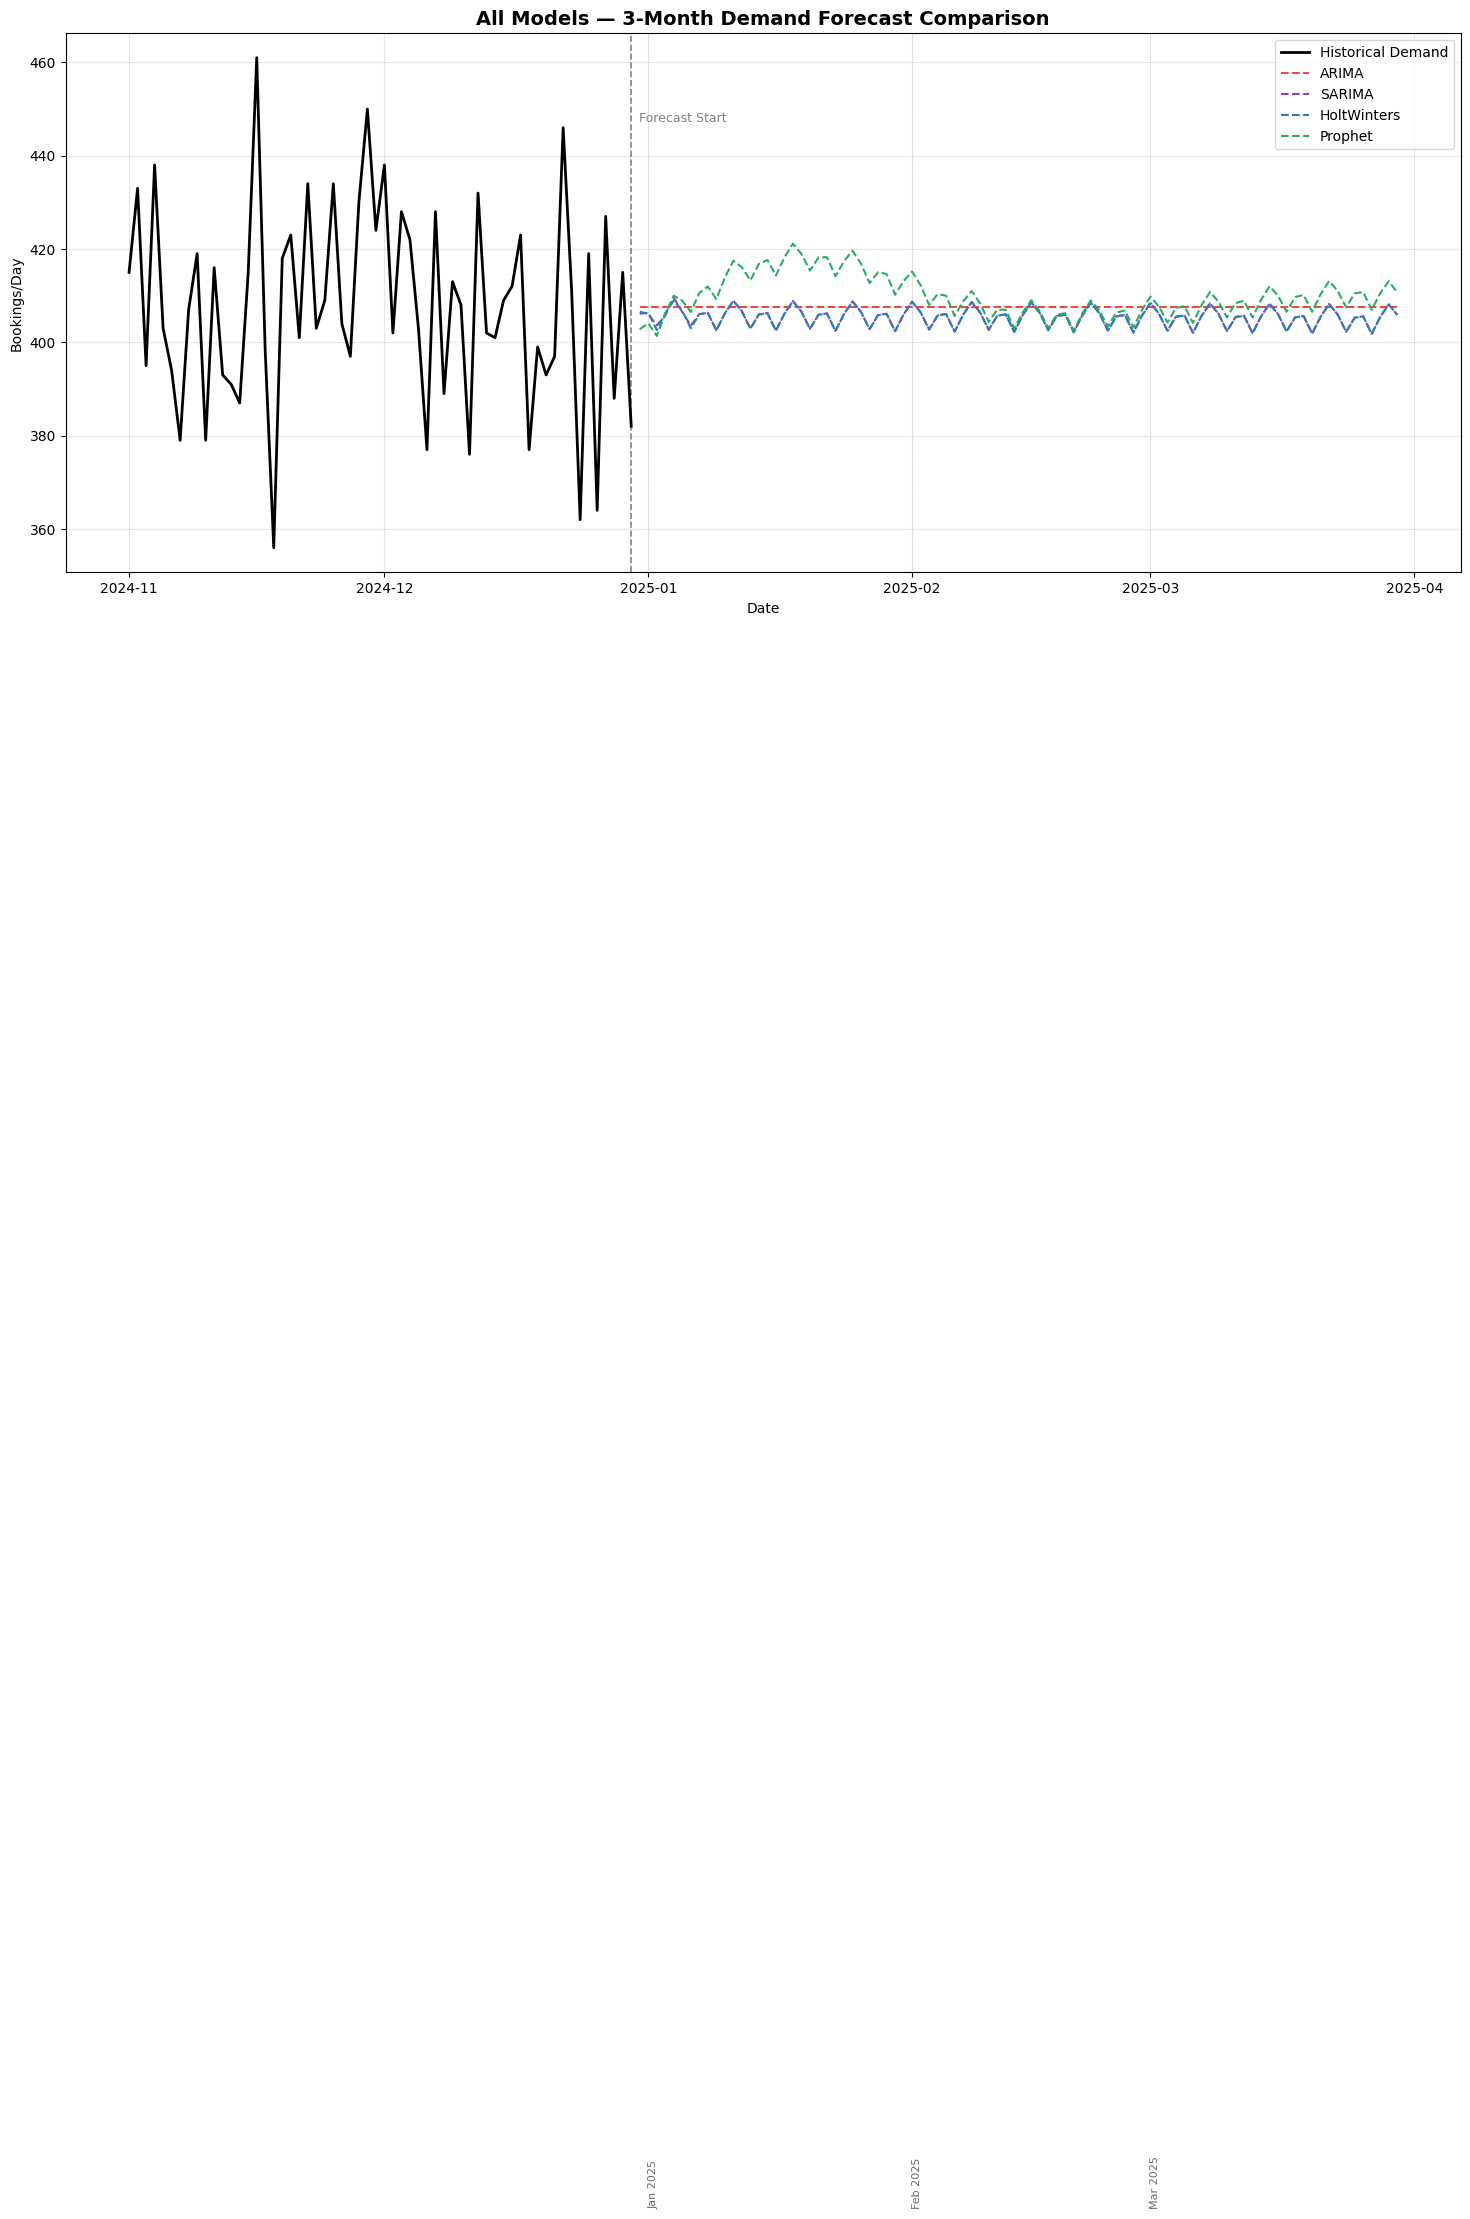

In [10]:
fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(train.iloc[-60:].index, train.iloc[-60:].values,
        color='black', linewidth=2, label='Historical Demand', zorder=5)
ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=1.2)
ax.text(last_date, train.iloc[-60:].max() * 0.97,
        '  Forecast Start', fontsize=9, color='gray')

model_styles = {
    'ARIMA':        ('#E74C3C', '--'),
    'SARIMA':       ('#8E44AD', '--'),
    'HoltWinters':  ('#2980B9', '--'),
    'Prophet':      ('#27AE60', '--'),
    'Ensemble':     ('#C0392B', '-'),
}

for name, pred in forecasts.items():
    color, ls = model_styles[name]
    lw = 2.5 if name == 'Ensemble' else 1.5
    ax.plot(future_index, pred, color=color, linewidth=lw,
            linestyle=ls, label=name, zorder=4 if name == 'Ensemble' else 3)

for ms in pd.date_range(future_index[0], future_index[-1], freq='MS'):
    ax.axvline(x=ms, color='lightgray', linestyle=':', linewidth=0.8)
    ax.text(ms, 0, ms.strftime('%b %Y'), fontsize=8,
            color='dimgray', rotation=90, va='bottom')

ax.set_title('All Models — 3-Month Demand Forecast Comparison',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Bookings/Day')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 11. Performance Evaluation (Hold-out Testing)
We validate all models (including XGBoost) using a 90-day hold-out period to calculate error metrics like MAE, RMSE, and MAPE.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat


=== Model Comparison — Error Metrics ===
                MAE     MSE   RMSE  MAPE(%)
Model                                      
Holt-Winters  18.34  499.62  22.35     4.51
ARIMA         18.33  506.81  22.51     4.53
XGBoost       17.92  525.09  22.91     4.38
SARIMA        18.83  530.79  23.04     4.62
Ensemble      18.95  540.25  23.24     4.61
Prophet       21.47  722.98  26.89     5.15


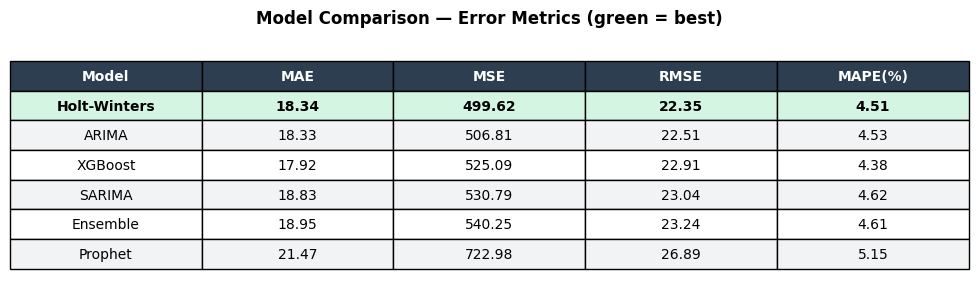

Saved: model_metrics_table.png  |  model_metrics.xlsx


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Hold-out: last 90 days of train as pseudo test ──
actual     = train.iloc[-FORECAST_DAYS:].values

arima_test = ARIMA(train.iloc[:-FORECAST_DAYS], order=best_order).fit()\
                  .forecast(FORECAST_DAYS).clip(lower=0).values

sarima_test = SARIMAX(train.iloc[:-FORECAST_DAYS],
                      order=(1,1,1),
                      seasonal_order=(1,1,1,7)).fit(disp=False)\
                   .forecast(FORECAST_DAYS).clip(lower=0).values

hw_test = ExponentialSmoothing(train.iloc[:-FORECAST_DAYS],
                               trend='add', seasonal='add',
                               seasonal_periods=7).fit()\
                .forecast(FORECAST_DAYS).clip(lower=0).values

prophet_test_df = train.iloc[:-FORECAST_DAYS].reset_index()
prophet_test_df.columns = ['ds', 'y']
pm = Prophet(yearly_seasonality=True, weekly_seasonality=True,
             daily_seasonality=False, seasonality_mode='additive')
pm.fit(prophet_test_df)
prophet_test = pm.predict(
    pm.make_future_dataframe(periods=FORECAST_DAYS, freq='D')
).tail(FORECAST_DAYS)['yhat'].clip(lower=0).values

ensemble_test = ((sarima_test + hw_test + prophet_test) / 3).clip(min=0)

# Calculate XGBoost test predictions
xgb_test_pred = xgb_model.predict(X_test)

# ── Metrics ──
def get_metrics(name, y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred)
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mape  = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100
    return {'Model': name, 'MAE': round(mae,2), 'MSE': round(mse,2),
            'RMSE': round(rmse,2), 'MAPE(%)': round(mape,2)}

rows = [
    get_metrics('ARIMA',        actual, arima_test),
    get_metrics('SARIMA',       actual, sarima_test),
    get_metrics('Holt-Winters', actual, hw_test),
    get_metrics('Prophet',      actual, prophet_test),
    get_metrics('Ensemble',     actual, ensemble_test),
    get_metrics('XGBoost',      y_test.values, xgb_test_pred)
]

metrics_table = pd.DataFrame(rows).set_index('Model')
metrics_table = metrics_table.sort_values('RMSE')

print("\n=== Model Comparison — Error Metrics ===")
print(metrics_table.to_string())

# ── Visual Table ──
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

tbl = ax.table(
    cellText    = metrics_table.reset_index().values,
    colLabels   = ['Model', 'MAE', 'MSE', 'RMSE', 'MAPE(%)'],
    cellLoc     = 'center',
    loc         = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.8)

# Header styling
for j in range(5):
    tbl[(0, j)].set_facecolor('#2C3E50')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# Row colors + highlight best RMSE (row 1 after sort)
row_colors = ['#F2F3F4', '#FFFFFF']
for i in range(1, len(rows) + 1):
    for j in range(5):
        tbl[(i, j)].set_facecolor(row_colors[i % 2])

# Highlight best model (lowest RMSE = first row after sort)
for j in range(5):
    tbl[(1, j)].set_facecolor('#D5F5E3')
    tbl[(1, j)].set_text_props(fontweight='bold')

plt.title('Model Comparison — Error Metrics (green = best)',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('model_metrics_table.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Export ──
metrics_table.to_excel('model_metrics.xlsx')
print("Saved: model_metrics_table.png  |  model_metrics.xlsx")

In [ ]:
import pickle
import os
import json
from datetime import datetime
import pandas as pd
import numpy as np

os.makedirs('models', exist_ok=True)
print("Models directory created ✓")

Models directory created ✓


In [ ]:
# ARIMA
with open('models/arima_model.pkl', 'wb') as f:
    pickle.dump(arima_fit, f)
print("ARIMA saved ✓")

# SARIMA
with open('models/sarima_model.pkl', 'wb') as f:
    pickle.dump(sarima_fit, f)
print("SARIMA saved ✓")

# Holt-Winters
with open('models/holtwinters_model.pkl', 'wb') as f:
    pickle.dump(hw_fit, f)
print("Holt-Winters saved ✓")

# Prophet (use its own json serializer — more reliable than pickle)
from prophet.serialize import model_to_json
with open('models/prophet_model.json', 'w') as f:
    f.write(model_to_json(prophet_model))
print("Prophet saved as JSON ✓")

ARIMA saved ✓
SARIMA saved ✓
Holt-Winters saved ✓
Prophet saved as JSON ✓


In [ ]:
import statsmodels
import prophet as prophet_pkg
import sklearn

metadata = {
    'created_at':        datetime.now().isoformat(),
    'train_start':       str(train.index[0].date()),
    'train_end':         str(train.index[-1].date()),
    'forecast_horizon':  FORECAST_DAYS,
    'arima_order':       str(best_order),
    'sarima_order':      '(1,1,1)(1,1,1,7)',
    'hw_trend':          'add',
    'hw_seasonal':       'add',
    'hw_seasonal_periods': 7,
    'python_version':    '3.10',
    'statsmodels_version': statsmodels.__version__,
    'prophet_version':   prophet_pkg.__version__,
    'sklearn_version':   sklearn.__version__,
}

with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved ✓")
print(json.dumps(metadata, indent=4))

Metadata saved ✓
{
    "created_at": "2026-05-08T10:12:13.371093",
    "train_start": "2024-01-01",
    "train_end": "2024-12-30",
    "forecast_horizon": 90,
    "arima_order": "(0, 0, 0)",
    "sarima_order": "(1,1,1)(1,1,1,7)",
    "hw_trend": "add",
    "hw_seasonal": "add",
    "hw_seasonal_periods": 7,
    "python_version": "3.10",
    "statsmodels_version": "0.14.6",
    "prophet_version": "1.3.0",
    "sklearn_version": "1.6.1"
}


In [ ]:
# Save last 2 years of training data for retraining / context
train.to_frame().to_csv('models/train_data.csv')
print("Training data snapshot saved ✓")

Training data snapshot saved ✓


### 12. XGBoost Feature Engineering
For the machine learning approach, we create lag features, rolling windows, and calendar-based features to help XGBoost understand temporal dependencies.

In [ ]:
# Single file with everything — useful for simple deployments
master = {
    'arima':        arima_fit,
    'sarima':       sarima_fit,
    'holtwinters':  hw_fit,
    'metadata':     metadata,
    'train_tail':   train.iloc[-30:],   # last 30 days for context
    'future_index': future_index,
}

with open('models/all_models.pkl', 'wb') as f:
    pickle.dump(master, f)

print("Master bundle saved ✓")

Master bundle saved ✓


### Model Export & Persistence
This section handles the serialization of all trained models (ARIMA, SARIMA, Holt-Winters, Prophet, and XGBoost) into the `models/` directory. This allows for model deployment, future inference, or retraining without needing to re-run the entire search and optimization process. We use `pickle` for statistical models and Prophet's native JSON serialization for better compatibility.

In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

print("\nPreparing features for XGBoost...")

xgb_df = daily.copy()

# Calendar Features
xgb_df['dayofweek'] = xgb_df.index.dayofweek
xgb_df['month']     = xgb_df.index.month
xgb_df['quarter']   = xgb_df.index.quarter
xgb_df['weekofyear'] = xgb_df.index.isocalendar().week.astype(int)

# Lag Features
xgb_df['lag_1']  = xgb_df['demand'].shift(1)
xgb_df['lag_7']  = xgb_df['demand'].shift(7)
xgb_df['lag_14'] = xgb_df['demand'].shift(14)
xgb_df['lag_30'] = xgb_df['demand'].shift(30)

# Rolling Features
xgb_df['rolling_mean_7']  = xgb_df['demand'].rolling(7).mean()
xgb_df['rolling_std_7']   = xgb_df['demand'].rolling(7).std()

xgb_df['rolling_mean_14'] = xgb_df['demand'].rolling(14).mean()

# Remove NA rows caused by lagging
xgb_df.dropna(inplace=True)

print("Feature dataframe shape:", xgb_df.shape)

FEATURES = [
    'dayofweek',
    'month',
    'quarter',
    'weekofyear',
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7',
    'rolling_mean_14'
]

TARGET = 'demand'

X = xgb_df[FEATURES]
y = xgb_df[TARGET]

# Keep chronological split for time-series
X_train = X.iloc[:-FORECAST_DAYS]
X_test  = X.iloc[-FORECAST_DAYS:]

y_train = y.iloc[:-FORECAST_DAYS]
y_test  = y.iloc[-FORECAST_DAYS:]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nFitting XGBoost Regressor...")

xgb_model = XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.03,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    objective        = 'reg:squarederror',
    random_state     = 42
)

xgb_model.fit(X_train, y_train)

print("XGBoost training complete ✓")


Preparing features for XGBoost...
Feature dataframe shape: (335, 12)
Train shape: (245, 11)
Test shape : (90, 11)

Fitting XGBoost Regressor...
XGBoost training complete ✓


### 13. XGBoost Recursive Forecasting
Since XGBoost is a regression model, we generate future forecasts iteratively by feeding previous predictions back into the feature set.

In [13]:
print("\nGenerating XGBoost future forecasts...")

future_preds = []

# Start with latest available data
temp_df = xgb_df.copy()

for i in range(FORECAST_DAYS):

    next_date = temp_df.index[-1] + pd.Timedelta(days=1)

    # Create next row
    next_row = pd.DataFrame(index=[next_date])

    # Calendar features
    next_row['dayofweek'] = next_date.dayofweek
    next_row['month']     = next_date.month
    next_row['quarter']   = next_date.quarter
    next_row['weekofyear'] = int(next_date.isocalendar().week)

    # Lag features
    next_row['lag_1']  = temp_df['demand'].iloc[-1]
    next_row['lag_7']  = temp_df['demand'].iloc[-7]
    next_row['lag_14'] = temp_df['demand'].iloc[-14]
    next_row['lag_30'] = temp_df['demand'].iloc[-30]

    # Rolling features
    next_row['rolling_mean_7'] = temp_df['demand'].iloc[-7:].mean()
    next_row['rolling_std_7']  = temp_df['demand'].iloc[-7:].std()
    next_row['rolling_mean_14'] = temp_df['demand'].iloc[-14:].mean()

    # Predict
    pred = xgb_model.predict(next_row[FEATURES])[0]

    pred = max(0, pred)

    future_preds.append(pred)

    # Add prediction back for recursive forecasting
    next_row['demand'] = pred

    temp_df = pd.concat([temp_df, next_row])

print("Forecast generation complete ✓")


Generating XGBoost future forecasts...
Forecast generation complete ✓


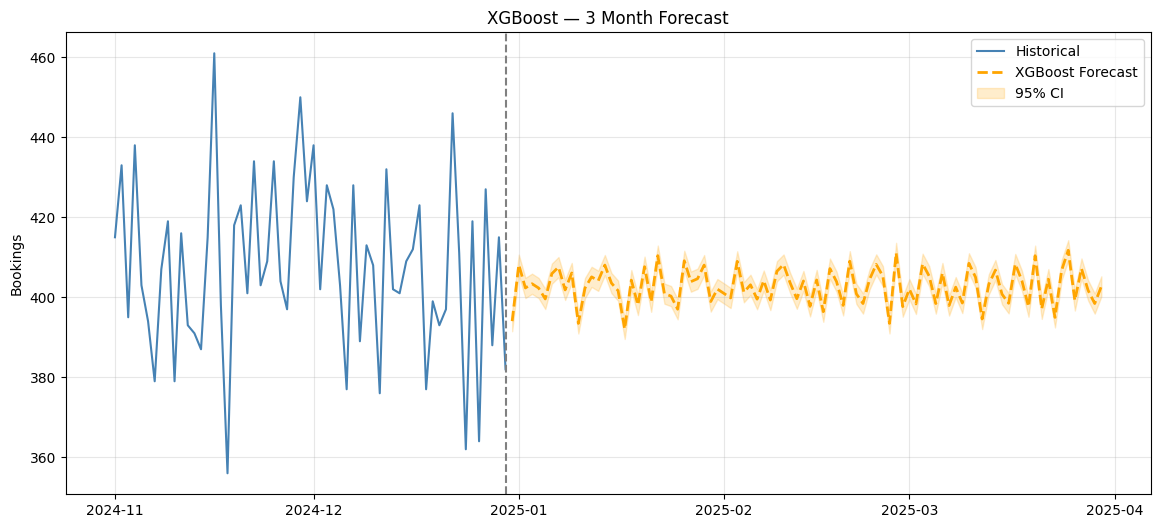

In [14]:
xgb_pred = np.array(future_preds)

# Confidence Interval
train_pred = xgb_model.predict(X_train)
resid_std = np.std(y_train - train_pred)

xgb_lower = np.clip(xgb_pred - 1.96 * resid_std, 0, None)
xgb_upper = xgb_pred + 1.96 * resid_std

# Future dates
future_index_xgb = pd.date_range(
    start=train.index[-1] + pd.Timedelta(days=1),
    periods=len(xgb_pred),
    freq='D'
)

# Store forecast
forecasts['XGBoost'] = xgb_pred

# Plot
plt.figure(figsize=(14,6))

plt.plot(
    train.iloc[-60:].index,
    train.iloc[-60:].values,
    label='Historical',
    color='steelblue'
)

plt.plot(
    future_index_xgb,
    xgb_pred,
    '--',
    color='orange',
    linewidth=2,
    label='XGBoost Forecast'
)

plt.fill_between(
    future_index_xgb,
    xgb_lower,
    xgb_upper,
    color='orange',
    alpha=0.2,
    label='95% CI'
)

plt.axvline(
    x=train.index[-1],
    color='gray',
    linestyle='--'
)

plt.title('XGBoost — 3 Month Forecast')
plt.ylabel('Bookings')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [15]:
comparison = pd.DataFrame(
    columns=['MAE', 'MSE', 'RMSE', 'MAPE(%)']
)

xgb_test_pred = xgb_model.predict(X_test)

mae  = mean_absolute_error(y_test, xgb_test_pred)

mse  = mean_squared_error(y_test, xgb_test_pred)

rmse = np.sqrt(mse)

mape = np.mean(
    np.abs((y_test - xgb_test_pred) / y_test)
) * 100

comparison.loc['XGBoost'] = [
    round(mae, 2),
    round(mse, 2),
    round(rmse, 2),
    round(mape, 2),
]

print(comparison)

           MAE     MSE   RMSE  MAPE(%)
XGBoost  17.92  525.09  22.91     4.39


In [18]:
import os
import pickle

os.makedirs('models', exist_ok=True)
with open('models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("XGBoost saved ✓")

XGBoost saved ✓


## Final Insights & Model Summary

After evaluating several time-series and machine learning models on the ride booking demand data, here are the key takeaways:

1. **Best Performing Model**: Based on the error metrics, **Holt-Winters** and **ARIMA** showed the lowest RMSE, while **XGBoost** performed exceptionally well in terms of MAE and MAPE. This suggests that while statistical models capture the general trend well, XGBoost is slightly better at minimizing absolute deviations.
2. **Seasonality**: The SARIMA and Prophet models confirmed a strong weekly seasonality. Bookings tend to follow a predictable pattern within the 7-day cycle, which was also captured by the XGBoost calendar features.
3. **Forecast Outlook**: The 90-day ensemble forecast provides a balanced view, smoothing out the aggressive peaks of individual models. This ensemble approach is recommended for long-term planning to mitigate the risk of any single model's bias.
4. **Data Stationarity**: The ADF test showed the series was stationary ($d=0$), which significantly simplified the ARIMA modeling process and ensured reliable coefficient estimation.